# Comparativa de la distribucción de palabras y caracteres entre los resumenes de FNSPID y el cuerpo del artículo de FinMultiTime

# Autor: Eloi Serantes Abal

Librerías usadas:

In [ ]:
!pip install sumy nltk

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 79.6 MB/s eta 0:00:00
  Created wheel for breadability: filename=breadability-0.1.20-py2.py3-none-any.whl size=21695 sha256=7b7fbad70267792a6c13f6156fc7821885245452c0595ed665817245f5c35867
  Stored in directory: /root/.cache/pip/wheels/32/99/64/59305409cacd03aa03e7bddf31a9db34b1fa7033bd41972662
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=9d041313e4a9ac01f2c6b89aec42800462c1c5c563121e80b31d8a9b85e47966
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built breadability docopt


In [ ]:
import pandas as pd
import zipfile
import gc
from huggingface_hub import hf_hub_download
import pyarrow as pa
import pyarrow.parquet as pq
import time
from google.colab import drive
import os
import time
import nltk
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Importaciones específicas de Sumy para LexRank
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Primero convertimos que el dataset de FinMultiTime se empaquete en un formato .parquet solo para el cuerpo del artículo

In [ ]:
def convertir_finn_a_parquet():
    dataset_id = "Wenyan0110/Multimodal-Dataset-Image_Text_Table_TimeSeries-for-Financial-Time-Series-Forecasting"
    archivo_zip = "text/sp500_news.zip"
    RUTA_SALIDA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Articles.parquet'

    print("="*75)
    print("INICIANDO CONVERSIÓN DE BIG DATA A PARQUET (MODO SEGURO RAM)")
    print("="*75)

    tiempo_inicio = time.time()

    print("Conectando con Hugging Face y descargando ZIP...")
    path_local = hf_hub_download(repo_id=dataset_id, filename=archivo_zip, repo_type="dataset")

    writer = None
    total_articulos_guardados = 0

    print("Procesando JSONL secuencialmente y escribiendo en Parquet...")
    with zipfile.ZipFile(path_local, 'r') as z:
        archivos_jsonl = [n for n in z.namelist() if n.lower().endswith('.jsonl')]
        total_archivos = len(archivos_jsonl)

        for i, archivo in enumerate(archivos_jsonl):
            with z.open(archivo) as f:
                df_temp = pd.read_json(f, lines=True)

                if 'Article' in df_temp.columns:
                    # Filtramos y limpiamos nulos
                    df_chunk = df_temp[['Article']].dropna().copy()
                    df_chunk['Article'] = df_chunk['Article'].astype(str)

                    df_chunk.reset_index(drop=True, inplace=True)

                    if not df_chunk.empty:
                        table = pa.Table.from_pandas(df_chunk, preserve_index=False)

                        if writer is None:
                            writer = pq.ParquetWriter(RUTA_SALIDA, table.schema, compression='snappy')

                        writer.write_table(table)
                        total_articulos_guardados += len(df_chunk)

                del df_temp
                if 'df_chunk' in locals():
                    del df_chunk
                gc.collect()

            if (i + 1) % 50 == 0 or (i + 1) == total_archivos:
                print(f"   [Progreso] Escritos {i + 1}/{total_archivos} archivos... ({total_articulos_guardados:,} artículos)")

    if writer:
        writer.close()

    tiempo_total = time.time() - tiempo_inicio
    print("\n" + "="*75)
    print(f"¡CONVERSIÓN COMPLETADA en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s!")
    print(f"Se ha guardado un Parquet con {total_articulos_guardados:,} artículos en: {RUTA_SALIDA}")
    print("="*75)

In [ ]:
convertir_finn_a_parquet()

INICIANDO CONVERSIÓN DE BIG DATA A PARQUET (MODO SEGURO RAM)
-> 1. Conectando con Hugging Face y descargando ZIP...
-> 2. Procesando JSONL secuencialmente y escribiendo en Parquet...
   [Progreso] Escritos 50/4694 archivos... (66,555 artículos)
   [Progreso] Escritos 100/4694 archivos... (104,995 artículos)
   [Progreso] Escritos 150/4694 archivos... (141,595 artículos)
   [Progreso] Escritos 200/4694 archivos... (193,702 artículos)
   [Progreso] Escritos 250/4694 archivos... (240,499 artículos)
   [Progreso] Escritos 300/4694 archivos... (279,894 artículos)
   [Progreso] Escritos 350/4694 archivos... (319,506 artículos)
   [Progreso] Escritos 400/4694 archivos... (337,874 artículos)
   [Progreso] Escritos 450/4694 archivos... (371,004 artículos)
   [Progreso] Escritos 500/4694 archivos... (404,417 artículos)
   [Progreso] Escritos 550/4694 archivos... (455,641 artículos)
   [Progreso] Escritos 600/4694 archivos... (486,663 artículos)
   [Progreso] Escritos 650/4694 archivos... (538,00

### Comparación distributiva de caracteres y palabras entre ambos datasets

1. Cargando y procesando FNSPID (Resúmenes)...
2. Procesando FinnMultiTime por lotes (3+ millones de registros)...
   Procesado lote 1 de 100,000 artículos...
   Procesado lote 2 de 100,000 artículos...
   Procesado lote 3 de 100,000 artículos...
   Procesado lote 4 de 100,000 artículos...
   Procesado lote 5 de 100,000 artículos...
   Procesado lote 6 de 100,000 artículos...
   Procesado lote 7 de 100,000 artículos...
   Procesado lote 8 de 100,000 artículos...
   Procesado lote 9 de 100,000 artículos...
   Procesado lote 10 de 100,000 artículos...
   Procesado lote 11 de 100,000 artículos...
   Procesado lote 12 de 100,000 artículos...
   Procesado lote 13 de 100,000 artículos...
   Procesado lote 14 de 100,000 artículos...
   Procesado lote 15 de 100,000 artículos...
   Procesado lote 16 de 100,000 artículos...
   Procesado lote 17 de 100,000 artículos...
   Procesado lote 18 de 100,000 artículos...
   Procesado lote 19 de 100,000 artículos...
   Procesado lote 20 de 100,000 artícul

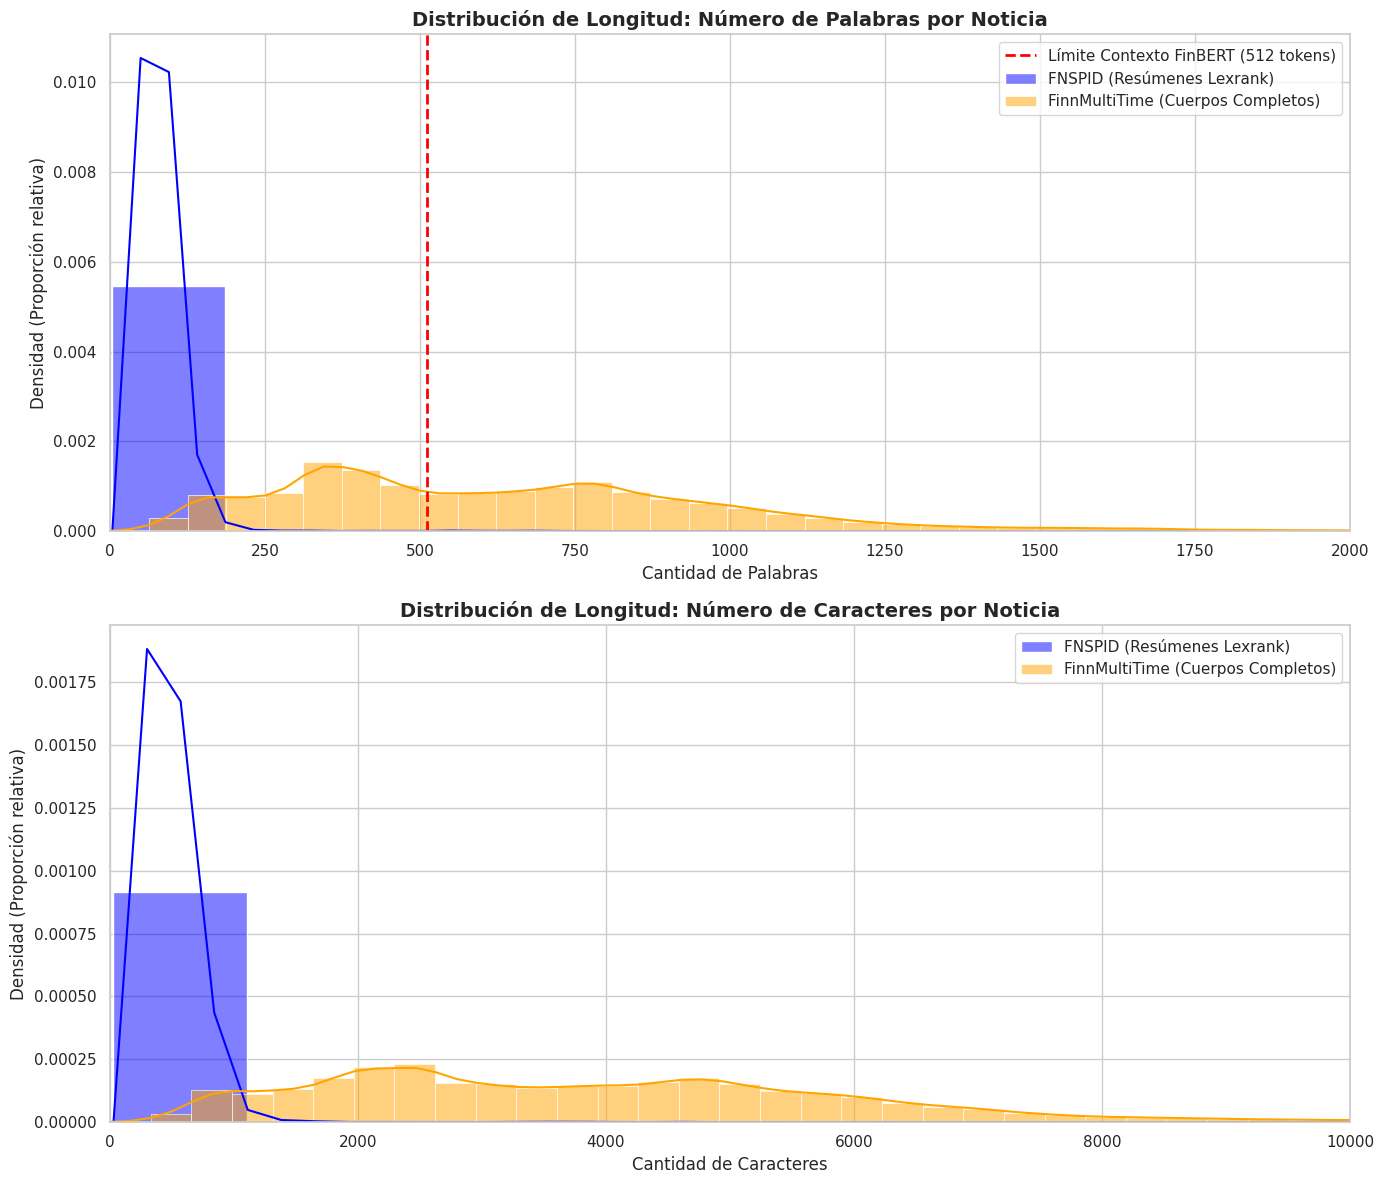


ESTADÍSTICAS GLOBALES DE PALABRAS

[ FNSPID - Resúmenes ]
count    729380.000000
mean         85.562538
std          55.706248
min           4.000000
25%          60.000000
50%          78.000000
75%         100.000000
max        9080.000000
Name: Word_Count, dtype: object

[ FinnMultiTime - 3M+ Cuerpos Completos ]
count    3049536.000000
mean         695.663530
std          608.592492
min            1.000000
25%          360.000000
50%          600.000000
75%          862.000000
max         6220.000000
Name: Word_Count, dtype: object


In [ ]:
RUTA_FNSPID = '/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares_resumenes.parquet'
RUTA_FINN_PARQUET = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Articles.parquet'

print("Cargando y procesando FNSPID (Resúmenes)...")
df_fnspid = pd.read_parquet(RUTA_FNSPID, columns=['Lexrank_summary']).dropna()
df_fnspid['Word_Count'] = df_fnspid['Lexrank_summary'].apply(lambda x: len(str(x).split()))
df_fnspid['Char_Count'] = df_fnspid['Lexrank_summary'].apply(lambda x: len(str(x)))
df_fnspid.drop(columns=['Lexrank_summary'], inplace=True)
gc.collect()

print("Procesando FinnMultiTime por lotes")
parquet_file = pq.ParquetFile(RUTA_FINN_PARQUET)
finn_word_counts = []
finn_char_counts = []

lote = 1
for batch in parquet_file.iter_batches(columns=['Article'], batch_size=100000):
    df_batch = batch.to_pandas()
    # Contamos palabras y caracteres, y los añadimos a nuestras listas globales
    finn_word_counts.extend(df_batch['Article'].str.split().str.len().tolist())
    finn_char_counts.extend(df_batch['Article'].str.len().tolist())

    del df_batch, batch
    gc.collect()
    print(f"   Procesado lote {lote} de 100,000 artículos...")
    lote += 1

# Convertimos las listas en un DataFrame ligero solo con números
df_finn_stats = pd.DataFrame({
    'Word_Count': finn_word_counts,
    'Char_Count': finn_char_counts
})

# Liberamos las listas originales
del finn_word_counts, finn_char_counts
gc.collect()

print("Generando gráficas de comparativa masiva...")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# NÚMERO DE PALABRAS
sns.histplot(df_fnspid['Word_Count'], color='blue', label='FNSPID (Resúmenes Lexrank)',
             kde=True, stat='density', alpha=0.5, ax=axes[0], bins=50)
sns.histplot(df_finn_stats['Word_Count'], color='orange', label='FinnMultiTime (Cuerpos Completos)',
             kde=True, stat='density', alpha=0.5, ax=axes[0], bins=100)

axes[0].axvline(512, color='red', linestyle='--', linewidth=2, label='Límite Contexto FinBERT (512 tokens)')
axes[0].set_title('Distribución de Longitud: Número de Palabras por Noticia', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de Palabras')
axes[0].set_ylabel('Densidad (Proporción relativa)')
axes[0].set_xlim(0, 2000)
axes[0].legend()

# NÚMERO DE CARACTERES
sns.histplot(df_fnspid['Char_Count'], color='blue', label='FNSPID (Resúmenes Lexrank)',
             kde=True, stat='density', alpha=0.5, ax=axes[1], bins=50)
sns.histplot(df_finn_stats['Char_Count'], color='orange', label='FinnMultiTime (Cuerpos Completos)',
             kde=True, stat='density', alpha=0.5, ax=axes[1], bins=100)

axes[1].set_title('Distribución de Longitud: Número de Caracteres por Noticia', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cantidad de Caracteres')
axes[1].set_ylabel('Densidad (Proporción relativa)')
axes[1].set_xlim(0, 10000)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ESTADÍSTICAS GLOBALES DE PALABRAS")
print("="*50)
print("\n[ FNSPID - Resúmenes ]")
print(df_fnspid['Word_Count'].describe().apply(lambda x: format(x, 'f')))
print("\n[ FinnMultiTime - 3M+ Cuerpos Completos ]")
print(df_finn_stats['Word_Count'].describe().apply(lambda x: format(x, 'f')))

## Probamos a hacer una pequeña prueba de resumen de artículos con LexRank para estimar el tiempo que va a tardar.

In [ ]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def debug_lexrank():
    RUTA_ENTRADA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Articles.parquet'

    print("="*75)
    print(f"LEXRANK (10 ARTÍCULOS)")
    print("="*75)

    try:
        parquet_file = pq.ParquetFile(RUTA_ENTRADA)
        lote = next(parquet_file.iter_batches(columns=['Article'], batch_size=10))
        df_test = lote.to_pandas()
    except FileNotFoundError:
        print("[!] No se encontró el Parquet.")
        return

    idioma = "english"
    stemmer = Stemmer(idioma)
    summarizer = LexRankSummarizer(stemmer)
    summarizer.stop_words = get_stop_words(idioma)

    resumenes = []

    print("-> Analizando...\n")
    for idx, texto in enumerate(df_test['Article']):
        try:
            if not isinstance(texto, str) or len(texto.split()) < 20:
                resumenes.append("TEXTO_DEMASIADO_CORTO")
                continue

            parser = PlaintextParser.from_string(texto, Tokenizer(idioma))
            resumen = summarizer(parser.document, 3)
            texto_resumido = " ".join([str(sentence) for sentence in resumen])
            resumenes.append(texto_resumido)
            if idx == 0:
                print("ÉXITO EN EL ARTÍCULO 1!\n")
                print("Original (primeras palabras):", texto[:150], "...")
                print("\nResumen LexRank:")
                print(texto_resumido)
                print("-" * 50)

        except Exception as e:
            print(f"ERROR EXACTO en el artículo {idx}: {str(e)}")
            resumenes.append("ERROR")

debug_lexrank()

🛠️ MODO DEPURACIÓN LEXRANK (10 ARTÍCULOS)
-> Analizando...

✅ ¡ÉXITO EN EL ARTÍCULO 1!

Original (primeras palabras): Representative Julie Johnson just filed new stock trades, which we received from a STOCK Act disclosure. You can see the full list of trades on Quiver ...

Resumen LexRank:
ORDINARY SHARES) Purchase of $MMM stock (3M COMPANY COMMON STOCK) To see all the trades, and to see details on the trade sizes and dates, see Quiver Quantitative's politician page for Representative Julie Johnson This article was originally published on Quiver News, read the full story. The views and opinions expressed herein are the views and opinions of the author and do not necessarily reflect those of Nasdaq, Inc.
--------------------------------------------------


## Pruebas rápidas para ver como funciona este algoritmo de resumen

In [ ]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def evaluar_articulos_aleatorios(num_ejemplos=5):
    RUTA_ENTRADA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Articles.parquet'

    try:
        # Extraemos un lote grande (2000 artículos) para asegurar tener variedad suficiente
        parquet_file = pq.ParquetFile(RUTA_ENTRADA)
        lote = next(parquet_file.iter_batches(columns=['Article'], batch_size=2000))
        df_test = lote.to_pandas()
    except FileNotFoundError:
        print("[!] No se encontró el archivo Parquet.")
        return

    # Filtramos para quedarnos solo con artículos largos (más de 300 palabras)
    df_largos = df_test[df_test['Article'].str.split().str.len() > 300].reset_index(drop=True)

    if df_largos.empty:
        print("No se encontraron artículos largos en este lote.")
        return

    # Ajustamos por si el lote no tiene 5 artículos largos
    cantidad_a_extraer = min(num_ejemplos, len(df_largos))

    # Elegimos los ejemplos al azar sin repetición
    articulos_elegidos = random.sample(df_largos['Article'].tolist(), cantidad_a_extraer)

    print("="*80)
    print(f"PRUEBA DE LEXRANK - {cantidad_a_extraer} ARTÍCULOS ALEATORIOS")
    print("="*80)

    # Configuración de LexRank
    idioma = "english"
    stemmer = Stemmer(idioma)
    summarizer = LexRankSummarizer(stemmer)
    summarizer.stop_words = get_stop_words(idioma)

    # Bucle para procesar e imprimir cada uno de los 5 artículos
    for i, articulo_original in enumerate(articulos_elegidos, 1):
        palabras_original = len(articulo_original.split())

        # Procesamiento
        parser = PlaintextParser.from_string(articulo_original, Tokenizer(idioma))
        resumen = summarizer(parser.document, 3) # Extraemos las 3 frases más relevantes
        texto_resumido = " ".join([str(sentence) for sentence in resumen])
        palabras_resumen = len(texto_resumido.split())

        # IMPRESIÓN DE RESULTADOS
        print(f"\n[{i}/{cantidad_a_extraer}] ARTÍCULO DE {palabras_original} PALABRAS")
        print("-" * 80)

        # Imprimimos solo los primeros ~800 caracteres del original
        print("TEXTO ORIGINAL (Fragmento inicial):")
        print(articulo_original[:800] + " [... El texto continúa ...]\n")

        print(f"RESUMEN LEXRANK ({palabras_resumen} palabras):")
        print(texto_resumido)
        print("="*80)

evaluar_articulos_aleatorios(5)

PRUEBA DE ESTRÉS LEXRANK - 5 ARTÍCULOS ALEATORIOS

[1/5] ARTÍCULO DE 313 PALABRAS
--------------------------------------------------------------------------------
TEXTO ORIGINAL (Fragmento inicial):
This week, several major companies will be reporting earnings. Among them are Zoom Video Communications (ZM), Baidu (BIDU), Snowflake (SNOW), Palo Alto Networks (PANW) and Target (TGT).
Ahead of this week’s major earnings announcements, TipRanks has calculated the expected moves of these companies’ stocks. We use the at-the-money straddle of the options whose post-earnings expiration dates are closest to the earnings announcement date.
Note that options volatility tends to be high in the days leading up to an earnings announcement, due to uncertainty around the earnings. Investors don’t know whether the earnings will be positive or negative, so the price of options (aka the option premium) rises.
Furthermore, after the earnings announcement, because the uncertainty has been resolved, the p 